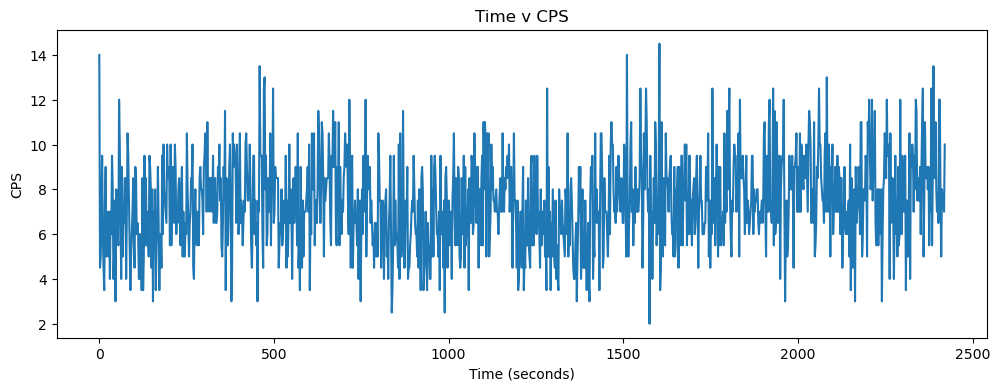

In [96]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("radiation_hike.csv")

fig, axs = plt.subplots(1)
fig.set_figheight(4)
fig.set_figwidth(12)

axs.set_title("Time v CPS")
axs.set_ylabel("CPS")
axs.set_xlabel("Time (seconds)")

readable_rad = data.copy()
readable_rad.iloc[:, 0:1] = data.iloc[:, 0:1] - 1778108250

# radvt = axs.plot(np.arange(0, 2*len(data), 2), data["cps"])
radvt = axs.plot(readable_rad["timestamp"], readable_rad["cps"])

In [4]:
# six locations. 1: first 2.5 minutes. 6: final 4ish minutes. 2: ~8 minute mark? 3-4 minutes. 3: ~15 minute mark? 5-6 minutes.
# 4: ~24 minute mark? 2-3 minutes. 5: ~30 minute mark? 2-3 minutes

# LOCATION ONE: T=1 - T=160
rad_loc1 = readable_rad[readable_rad["timestamp"] > 0]
tcounts1 = np.sum(rad_loc1["cps"])
rad_loc1 = rad_loc1[rad_loc1["timestamp"] < 165]
rad1mean = np.sum(rad_loc1["cps"]) / len(rad_loc1)
print("Mean of counts at location one: " + str(rad1mean))
# finding uncertainty:
rad1unc = np.sqrt(tcounts1) / len(rad_loc1)
print("Uncertainty on the mean: " + str(rad1unc))

# LOCATION TWO: T=480 - T=700
rad_loc2 = readable_rad[readable_rad["timestamp"] > 480]
tcounts2 = np.sum(rad_loc2["cps"])
rad_loc2 = rad_loc2[rad_loc2["timestamp"] < 700]
rad2mean = np.sum(rad_loc2["cps"]) / len(rad_loc2)
print("Mean of counts at location two: " + str(rad2mean))
rad2unc = np.sqrt(tcounts2) / len(rad_loc2)
print("Uncertainty on the mean: " + str(rad2unc))

# LOCATION THREE: T=900 - T=1230
rad_loc3 = readable_rad[readable_rad["timestamp"] > 900]
tcounts3 = np.sum(rad_loc3["cps"])
rad_loc3 = rad_loc3[rad_loc3["timestamp"] < 1230]
rad3mean = np.sum(rad_loc3["cps"]) / len(rad_loc3)
print("Mean of counts at location three: " + str(rad3mean))
rad3unc = np.sqrt(tcounts3) / len(rad_loc3)
print("Uncertainty on the mean: " + str(rad3unc))

# LOCATION FOUR: T=1440 - T=1600
rad_loc4 = readable_rad[readable_rad["timestamp"] > 1440]
tcounts4 = np.sum(rad_loc4["cps"])
rad_loc4 = rad_loc4[rad_loc4["timestamp"] < 1600]
rad4mean = np.sum(rad_loc4["cps"]) / len(rad_loc4)
print("Mean of counts at location four: " + str(rad4mean))
rad4unc = np.sqrt(tcounts4) / len(rad_loc4)
print("Uncertainty on the mean: " + str(rad4unc))

# LOCATION FIVE: T=1900 - T=2050
rad_loc5 = readable_rad[readable_rad["timestamp"] > 1900]
tcounts5 = np.sum(rad_loc5["cps"])
rad_loc5 = rad_loc5[rad_loc5["timestamp"] < 2050]
rad5mean = np.sum(rad_loc5["cps"]) / len(rad_loc5)
print("Mean of counts at location five: " + str(rad5mean))
rad5unc = np.sqrt(tcounts5) / len(rad_loc5)
print("Uncertainty on the mean: " + str(rad5unc))

# LOCATION SIX: T=2200 - T=end
rad_loc6 = readable_rad[readable_rad["timestamp"] > 2200]
tcounts6 = np.sum(rad_loc6["cps"])
rad6mean = np.sum(rad_loc6["cps"]) / len(rad_loc6)
print("Mean of counts at location six: " + str(rad6mean))
rad6unc = np.sqrt(tcounts6) / len(rad_loc6)
print("Uncertainty on the mean: " + str(rad6unc))

Mean of counts at location one: 6.530487804878049
Uncertainty on the mean: 1.1489656005379412
Mean of counts at location two: 7.63302752293578
Uncertainty on the mean: 0.7761381134700686
Mean of counts at location three: 7.00920245398773
Uncertainty on the mean: 0.460899140392465
Mean of counts at location four: 7.791139240506329
Uncertainty on the mean: 0.7834308009649971
Mean of counts at location five: 8.27027027027027
Uncertainty on the mean: 0.6172732754354728
Mean of counts at location six: 8.20183486238532
Uncertainty on the mean: 0.27431039243534044


<ErrorbarContainer object of 3 artists>

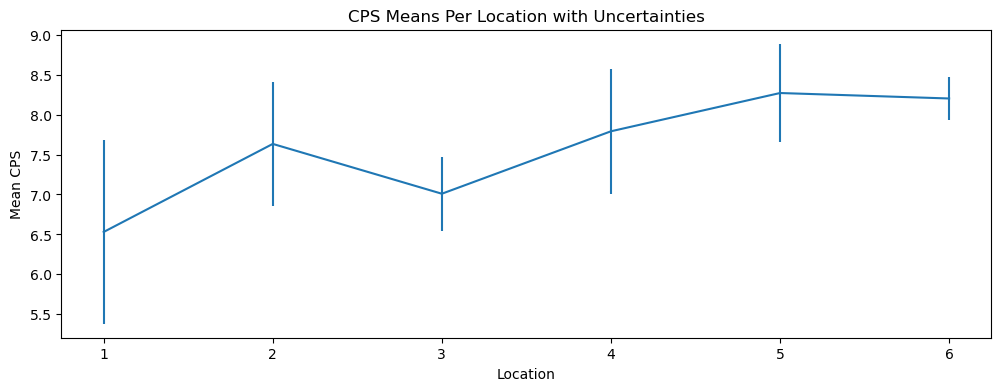

In [97]:
# plot of each of the cps data points
means = [rad1mean, rad2mean, rad3mean, rad4mean, rad5mean, rad6mean]
uncertainties = [rad1unc, rad2unc, rad3unc, rad4unc, rad5unc, rad6unc]

fig, axs = plt.subplots(1)
fig.set_figheight(4)
fig.set_figwidth(12)
axs.set_title("CPS Means Per Location with Uncertainties")
axs.set_ylabel("Mean CPS")
axs.set_xlabel("Location")
axs.errorbar([1, 2, 3, 4, 5, 6], means, yerr=uncertainties)

(array([ 0.,  0.,  0.,  2.,  3., 10., 10., 22., 21., 17.,  9.,  5.,  9.,
         1.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14.]),
 <BarContainer object of 14 artists>)

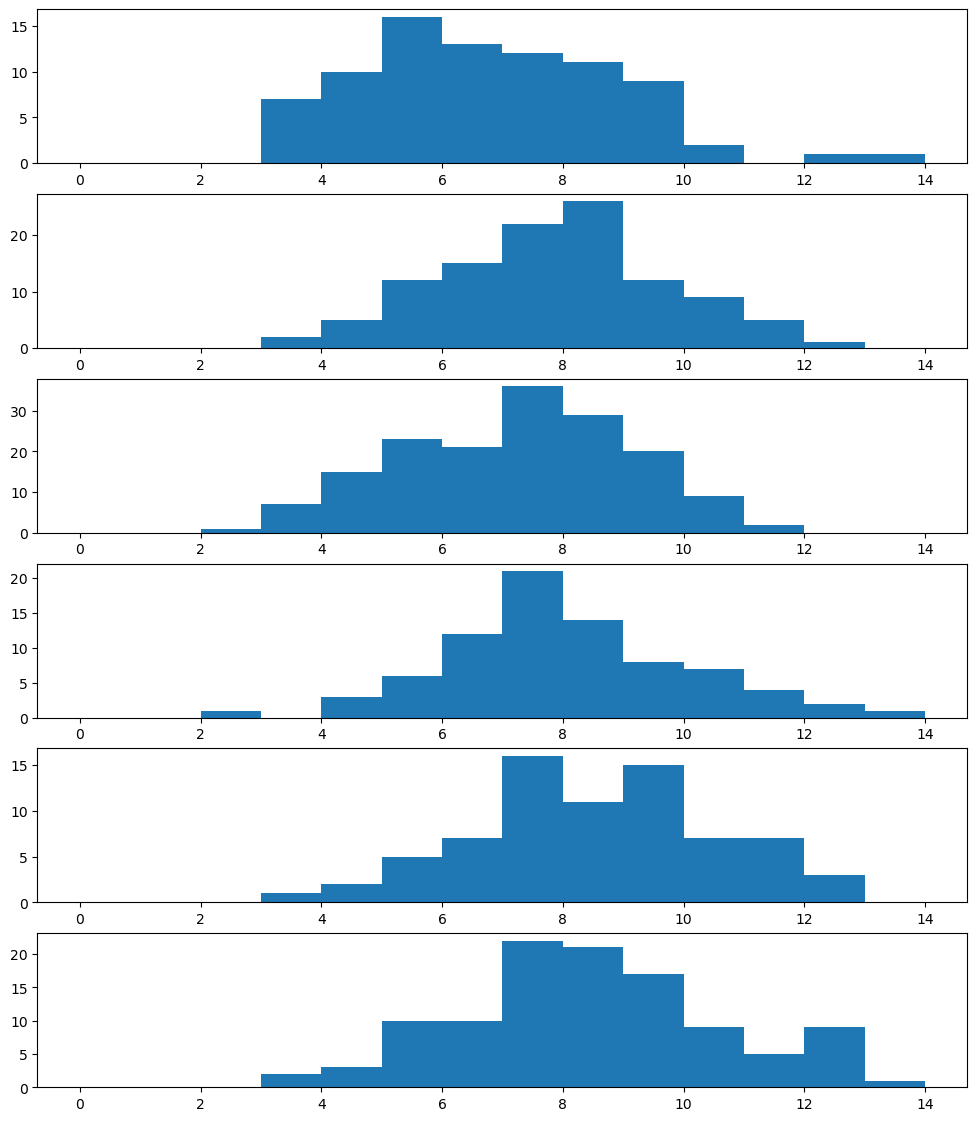

In [104]:
# checking poisson-ness
fig, axs = plt.subplots(6)
fig.set_figheight(14)
fig.set_figwidth(12)
axs[0].hist(rad_loc1["cps"], bins=range(0, 15))
axs[1].hist(rad_loc2["cps"], bins=range(0, 15))
axs[2].hist(rad_loc3["cps"], bins=range(0, 15))
axs[3].hist(rad_loc4["cps"], bins=range(0, 15))
axs[4].hist(rad_loc5["cps"], bins=range(0, 15))
axs[5].hist(rad_loc6["cps"], bins=range(0, 15))

Text(0.5, 0, 'Counts Per Second')

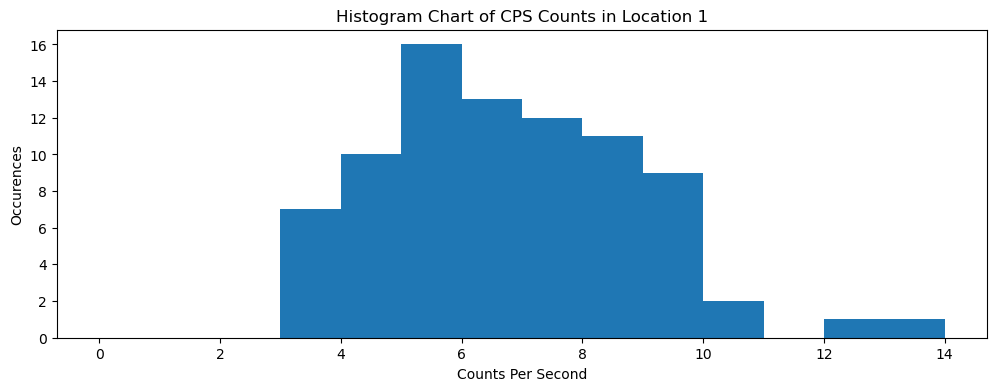

In [105]:
# with labels
fig, axs = plt.subplots(1)
fig.set_figheight(4)
fig.set_figwidth(12)
axs.hist(rad_loc1["cps"], bins=range(0, 15))
axs.set_title("Histogram Chart of CPS Counts in Location 1")
axs.set_ylabel("Occurences")
axs.set_xlabel("Counts Per Second")

In [106]:
# trying to bootstrap
bootstrap_samples = 1000
loc1size = len(rad_loc1["cps"])
loc2size = len(rad_loc2["cps"])
loc3size = len(rad_loc3["cps"])
loc4size = len(rad_loc4["cps"])
loc5size = len(rad_loc5["cps"])
loc6size = len(rad_loc6["cps"])

mean_list = []
var_list = []

for i in range(1000):
    sample = np.random.choice(rad_loc1["cps"], size=loc1size)
    samp_mean = np.mean(sample)
    samp_var = np.var(sample)
    mean_list.append(samp_mean)
    var_list.append(samp_var)
print("Mean of Location 1: " + str(np.mean(mean_list)) + ", Variance: " + str(np.mean(var_list)) + ", Ratio: " + str(np.mean(mean_list) / np.mean(var_list)))
print("Mean interval: " + str(np.min(mean_list)) + ", " + str(np.max(mean_list)) + ". Variance interval: " + str(np.min(var_list)) + ", " + str(np.max(var_list)))
mean_list.clear()
var_list.clear()

for i in range(1000):
    sample = np.random.choice(rad_loc2["cps"], size=loc2size)
    samp_mean = np.mean(sample)
    samp_var = np.var(sample)
    mean_list.append(samp_mean)
    var_list.append(samp_var)
print("Mean of Location 2: " + str(np.mean(mean_list)) + ", Variance: " + str(np.mean(var_list)) + ", Ratio: " + str(np.mean(mean_list) / np.mean(var_list)))
print("Mean interval: " + str(np.min(mean_list)) + ", " + str(np.max(mean_list)) + ". Variance interval: " + str(np.min(var_list)) + ", " + str(np.max(var_list)))
mean_list.clear()
var_list.clear()

for i in range(1000):
    sample = np.random.choice(rad_loc3["cps"], size=loc3size)
    samp_mean = np.mean(sample)
    samp_var = np.var(sample)
    mean_list.append(samp_mean)
    var_list.append(samp_var)
print("Mean of Location 3: " + str(np.mean(mean_list)) + ", Variance: " + str(np.mean(var_list)) + ", Ratio: " + str(np.mean(mean_list) / np.mean(var_list)))
print("Mean interval: " + str(np.min(mean_list)) + ", " + str(np.max(mean_list)) + ". Variance interval: " + str(np.min(var_list)) + ", " + str(np.max(var_list)))
mean_list.clear()
var_list.clear()

for i in range(1000):
    sample = np.random.choice(rad_loc4["cps"], size=loc4size)
    samp_mean = np.mean(sample)
    samp_var = np.var(sample)
    mean_list.append(samp_mean)
    var_list.append(samp_var)
print("Mean of Location 4: " + str(np.mean(mean_list)) + ", Variance: " + str(np.mean(var_list)) + ", Ratio: " + str(np.mean(mean_list) / np.mean(var_list)))
print("Mean interval: " + str(np.min(mean_list)) + ", " + str(np.max(mean_list)) + ". Variance interval: " + str(np.min(var_list)) + ", " + str(np.max(var_list)))

mean_list.clear()
var_list.clear()

for i in range(1000):
    sample = np.random.choice(rad_loc5["cps"], size=loc5size)
    samp_mean = np.mean(sample)
    samp_var = np.var(sample)
    mean_list.append(samp_mean)
    var_list.append(samp_var)
print("Mean of Location 5: " + str(np.mean(mean_list)) + ", Variance: " + str(np.mean(var_list)) + ", Ratio: " + str(np.mean(mean_list) / np.mean(var_list)))
print("Mean interval: " + str(np.min(mean_list)) + ", " + str(np.max(mean_list)) + ". Variance interval: " + str(np.min(var_list)) + ", " + str(np.max(var_list)))
mean_list.clear()
var_list.clear()

for i in range(1000):
    sample = np.random.choice(rad_loc6["cps"], size=loc6size)
    samp_mean = np.mean(sample)
    samp_var = np.var(sample)
    mean_list.append(samp_mean)
    var_list.append(samp_var)
print("Mean of Location 6: " + str(np.mean(mean_list)) + ", Variance: " + str(np.mean(var_list)) + ", Ratio: " + str(np.mean(mean_list) / np.mean(var_list)))
print("Mean interval: " + str(np.min(mean_list)) + ", " + str(np.max(mean_list)) + ". Variance interval: " + str(np.min(var_list)) + ", " + str(np.max(var_list)))
mean_list.clear()
var_list.clear()

Mean of Location 1: 6.526963414634146, Variance: 4.538518441403927, Ratio: 1.4381264500525246
Mean interval: 5.780487804878049, 7.426829268292683. Variance interval: 2.4102096966091615, 7.963749256395003
Mean of Location 2: 7.633155963302752, Variance: 3.4110424627556606, Ratio: 2.23777805367342
Mean interval: 6.981651376146789, 8.169724770642201. Variance interval: 1.851233061190136, 4.7928204696574355
Mean of Location 3: 7.0093773006134965, Variance: 3.4833625089389892, Ratio: 2.0122445719117845
Mean interval: 6.598159509202454, 7.460122699386503. Variance interval: 2.6233768677782376, 4.479976664533855
Mean of Location 4: 7.791917721518988, Variance: 4.106555119371896, Ratio: 1.897434101094149
Mean interval: 7.10126582278481, 8.620253164556962. Variance interval: 1.9617048549911882, 6.964749238904024
Mean of Location 5: 8.277108108108106, Variance: 4.068907505478451, Ratio: 2.034233537371802
Mean interval: 7.54054054054054, 9.006756756756756. Variance interval: 2.3322224251278305, 5

Explanation: Due to varying times of measurement, with some periods only measuring for about 2.5 minutes, it's possible that the bimodal-appearing distributions from the above histograms are actually noise rather than clear signs of a non-poisson distribution. In order to determine whether a distribution is actually poisson, we are using the bootstrap method!

The bootstrap method basically just means taking a bunch of random replaced samples from the recorded data and doing that a bajillion times to see whether the means or standard deviations are precise. In this context, we are using it to test poisson; we know that, in poisson statistics, the variance should be equal to the mean. The fact that all of these variances are below the mean shows that our radiation detector itself (likely due to the fact that it was tucked inside our black box) probably missed a good number of counts. With this in mind, the increased relative variance in Location 1 combined with the strange distribution pattern of our histogram data is likely a sign that there are conflicting radiation sources.